# Data Analyst Job Scraper Portfolio Project

## Project Overview
This project demonstrates web scraping and data analysis skills by building a scraper for data analyst job listings on ejobs.ro. As an aspiring data analyst, this project showcases:
- **Web Scraping**: Using Python libraries like Requests, BeautifulSoup, and Selenium to extract data from websites.
- **Data Cleaning**: Processing and structuring raw scraped data.
- **Data Analysis & Visualization**: Analyzing job market trends using Pandas and Plotly.
- **Automation**: Handling pagination and dynamic content.

## Skills Demonstrated
- Python programming
- Web scraping (static and dynamic)
- Data manipulation with Pandas
- Data visualization
- Problem-solving and debugging
- Best practices for ethical scraping (respecting robots.txt, rate limiting)

## Data Source
- Website: https://www.ejobs.ro/locuri-de-munca/data-analyst
- Scraped fields: Job Title, Company, Location, Salary Range
- Note: Salary data is often "Confidential"; this highlights real-world data quality issues.

## Ethical Considerations
- Only scrape public data.
- Respect website terms of service.
- Use delays to avoid overloading servers.
- This is for educational/portfolio purposes only.

In [30]:
%pip install pandas beautifulsoup4 requests selenium webdriver-manager plotly matplotlib nbformat

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.3 MB 14.3 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.3 MB 17.9 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 16.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 23.9 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------  7.1/7.2 MB 34.5 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 31.1 MB/s  0:00:00

   --------- ------------------------------  3/13 [pillow]
   --------- ------------------------------  3/13 [pillow]
   --------------- ------------------------  5/13 [fonttools]
   --------------- ------------------------  5/13 [fonttools]
   --------------- ------------------------  5/13 [fonttools]
   --------------- ----------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
# Import necessary libraries
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import plotly.express as px
import plotly.graph_objects as go

# Data Analyst Job Scraper Portfolio Project

## Project Overview
This project demonstrates web scraping and data analysis skills by building a scraper for data analyst job listings on ejobs.ro. As an aspiring data analyst, this project showcases:
- **Web Scraping**: Using Python libraries like Requests, BeautifulSoup, and Selenium to extract data from websites.
- **Data Cleaning**: Processing and structuring raw scraped data.
- **Data Analysis & Visualization**: Analyzing job market trends using Pandas and Plotly.
- **Automation**: Handling pagination and dynamic content.

## Skills Demonstrated
- Python programming
- Web scraping (static and dynamic)
- Data manipulation with Pandas
- Data visualization
- Problem-solving and debugging
- Best practices for ethical scraping (respecting robots.txt, rate limiting)

## Data Source
- Website: https://www.ejobs.ro/locuri-de-munca/data-analyst
- Scraped fields: Job Title, Company, Location, Salary Range
- Note: Salary data is often "Confidential"; this highlights real-world data quality issues.

## Ethical Considerations
- Only scrape public data.
- Respect website terms of service.
- Use delays to avoid overloading servers.
- This is for educational/portfolio purposes only.

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://www.ejobs.ro/locuri-de-munca/data-analyst"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/121.0.0.0"}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.content, "html.parser")

# eJobs stores jobs in a specific list. We find all "JobCard" elements.
job_cards = soup.find_all('div', class_='JobCard')

jobs_list = []

for card in job_cards:
    # 1. Extract Title
    title_tag = card.find('a', class_='JobCard-title')
    title = title_tag.get_text(strip=True) if title_tag else "N/A"
    
    # 2. Extract Company
    company_tag = card.find('a', class_='JobCard-company')
    company = company_tag.get_text(strip=True) if company_tag else "N/A"
    
    # 3. Extract Location
    location_tag = card.find('span', class_='JobCard-location')
    location = location_tag.get_text(strip=True) if location_tag else "N/A"
    
    # 4. Extract Salary (The most valuable part!)
    salary_tag = card.find('div', class_='JobCard-salary')
    salary = salary_tag.get_text(strip=True) if salary_tag else "Confidential"
    
    jobs_list.append({
        "Job Title": title,
        "Company": company,
        "Location": location,
        "Salary Range": salary
    })

# Turn it into a beautiful Table (DataFrame)
df = pd.DataFrame(jobs_list)

# Save it to your computer so you can show it in an interview
df.to_csv("ejobs_data_analyst_romania.csv", index=False)

print(f"Done! Scraped {len(df)} jobs.")
df.head()

Done! Scraped 0 jobs.


""


In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://www.ejobs.ro/locuri-de-munca/data-analyst"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/121.0.0.0"}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.content, "html.parser")

# We are using a more 'flexible' search that looks for any <div> 
# that contains 'JobCard' in its class name
job_cards = soup.find_all('div', class_=lambda x: x and 'JobCard' in x)

job_data = []

for card in job_cards:
    # We find the title by looking for the main link inside the card
    title_tag = card.find('a', class_=lambda x: x and 'title' in x.lower())
    company_tag = card.find('a', class_=lambda x: x and 'company' in x.lower())
    
    if title_tag:
        job_data.append({
            "Title": title_tag.get_text(strip=True),
            "Company": company_tag.get_text(strip=True) if company_tag else "N/A",
            "Location": "Romania" # Simplified for this test
        })

df = pd.DataFrame(job_data)
print(f"Success! Scraped {len(df)} jobs.")
df.head()

Success! Scraped 0 jobs.


""


In [5]:
print(soup.prettify()[:1000])

<!DOCTYPE html>
<html lang="ro">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width, initial-scale=1, maximum-scale=1, viewport-fit=cover" name="viewport"/>
  <title>
   Locuri de Munca Data analyst • 1234 Joburi • Martie 2026 - eJobs
  </title>
  <style>
   a,abbr,acronym,address,applet,article,aside,audio,b,big,blockquote,body,canvas,caption,center,cite,code,dd,del,details,dfn,div,dl,dt,em,embed,fieldset,figcaption,figure,footer,form,h1,h2,h3,h4,h5,h6,header,hgroup,html,i,iframe,img,ins,kbd,label,legend,li,mark,menu,nav,object,ol,output,p,pre,q,ruby,s,samp,section,small,span,strike,strong,sub,summary,sup,table,tbody,td,tfoot,th,thead,time,tr,tt,u,ul,var,video{border:0;font-family:Open Sans,Helvetica,Arial,sans-serif;margin:0;padding:0;vertical-align:baseline}article,aside,details,figcaption,figure,footer,header,hgroup,menu,nav,section{display:block}ol,ul{list-style:none}blockquote:after,blockquote:before,q:after,q:before{content:"";content:none}table{border-collaps

In [22]:
# Web Scraping Section: Scrape Data Analyst Jobs from ejobs.ro

def scrape_ejobs_jobs(pages=5):
    """
    Scrape data analyst job listings from ejobs.ro across multiple pages.

    Args:
        pages (int): Number of pages to scrape (default 5).

    Returns:
        pd.DataFrame: DataFrame with job data.
    """
    url_base = "https://www.ejobs.ro/locuri-de-munca/data-analyst"
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/121.0.0.0"}
    all_jobs = []

    for page in range(1, pages + 1):
        url = f"{url_base}/pagina{page}" if page > 1 else url_base
        response = requests.get(url, headers=headers)
        if response.status_code != 200:
            print(f"Failed to fetch page {page}")
            break

        soup = BeautifulSoup(response.content, "html.parser")

        # Find job cards (featured jobs)
        job_cards = soup.find_all('div', class_='job-card-content-middle')

        for card in job_cards:
            # Extract details
            title = card.find('h2').get_text(strip=True) if card.find('h2') else "N/A"
            company = card.find('h3').get_text(strip=True) if card.find('h3') else "N/A"

            # Location detection
            location = "N/A"
            text = card.get_text()
            locations = ["București", "Cluj-Napoca", "Iași", "Timișoara", "Brașov", "Constanța", "Craiova", "Galați", "Ploiești", "Oradea"]
            for loc in locations:
                if loc in text:
                    location = loc
                    break

            # Salary (attempt from job page)
            job_link = card.find('a', href=lambda x: x and '/user/locuri-de-munca/' in x)
            salary = "Confidential"
            if job_link:
                job_url = "https://www.ejobs.ro" + job_link['href']
                job_response = requests.get(job_url, headers=headers)
                if job_response.status_code == 200:
                    job_soup = BeautifulSoup(job_response.content, "html.parser")
                    salary_elem = job_soup.find('span', class_=lambda x: x and 'salary' in x.lower()) or \
                                  job_soup.find(string=lambda s: s and ('RON' in str(s) or 'EUR' in str(s)))
                    if salary_elem:
                        salary = salary_elem.get_text(strip=True) if hasattr(salary_elem, 'get_text') else str(salary_elem).strip()
                time.sleep(0.5)  # Polite delay

            all_jobs.append({
                "Job Title": title,
                "Company": company,
                "Location": location,
                "Salary Range": salary
            })

        print(f"Scraped {len(job_cards)} jobs from page {page}")
        time.sleep(1)  # Delay between pages

    df = pd.DataFrame(all_jobs).drop_duplicates()
    return df

# Run the scraper
df_jobs = scrape_ejobs_jobs(pages=5)
print(f"Total unique jobs scraped: {len(df_jobs)}")
df_jobs.head()

Scraped 3 jobs from page 1
Scraped 3 jobs from page 2
Scraped 3 jobs from page 3
Scraped 3 jobs from page 4
Scraped 3 jobs from page 5
Total unique jobs scraped: 15


,Job Title,Company,Location,Salary Range
0,Senior Data Analyst,PPC Energy,București,Confidential
1,Marketing Automation Data Analyst,PPC Energy,București,6000 RON net / lună
2,Senior Data Analyst,PPC Energy,București,5000 - 7000 RON net / lună
3,Junior Accounts Payable Analyst (German Speaking),Total Global Services Bucharest SRL,București,Confidential
4,Electronic Data Interchange Engineer,Sales Consulting,Cluj-Napoca,Confidential


In [23]:
# Data Cleaning Section

# Load data (in case running separately)
# df_jobs = pd.read_csv("ejobs_data_analyst_romania.csv")

# Clean and standardize data
df_jobs['Location'] = df_jobs['Location'].fillna('Unknown')
df_jobs['Company'] = df_jobs['Company'].fillna('Unknown')

# Extract salary numbers for analysis (simple regex for RON/EUR)
import re
def extract_salary_num(salary_str):
    match = re.search(r'(\d+(?:\.\d+)?)', str(salary_str))
    return float(match.group(1)) if match else None

df_jobs['Salary_Num'] = df_jobs['Salary Range'].apply(extract_salary_num)

# Categorize job titles (e.g., Senior, Junior)
def categorize_title(title):
    title_lower = title.lower()
    if 'senior' in title_lower:
        return 'Senior'
    elif 'junior' in title_lower or 'entry' in title_lower:
        return 'Junior'
    else:
        return 'Mid-level'

df_jobs['Level'] = df_jobs['Job Title'].apply(categorize_title)

print("Cleaned data:")
df_jobs.head()

Cleaned data:


,Job Title,Company,Location,Salary Range,Salary_Num,Level
0,Senior Data Analyst,PPC Energy,București,Confidential,NaN,Senior
1,Marketing Automation Data Analyst,PPC Energy,București,6000 RON net / lună,6000.0,Mid-level
2,Senior Data Analyst,PPC Energy,București,5000 - 7000 RON net / lună,5000.0,Senior
3,Junior Accounts Payable Analyst (German Speaking),Total Global Services Bucharest SRL,București,Confidential,NaN,Junior
4,Electronic Data Interchange Engineer,Sales Consulting,Cluj-Napoca,Confidential,NaN,Mid-level


Summary Statistics:
                  Job Title     Company   Location  Salary Range  \
count                    15          15         15            15   
unique                   14          13          3             5   
top     Senior Data Analyst  PPC Energy  București  Confidential   
freq                      2           3         10             9   
mean                    NaN         NaN        NaN           NaN   
std                     NaN         NaN        NaN           NaN   
min                     NaN         NaN        NaN           NaN   
25%                     NaN         NaN        NaN           NaN   
50%                     NaN         NaN        NaN           NaN   
75%                     NaN         NaN        NaN           NaN   
max                     NaN         NaN        NaN           NaN   

          Salary_Num      Level  
count       3.000000         15  
unique           NaN          3  
top              NaN  Mid-level  
freq             NaN       

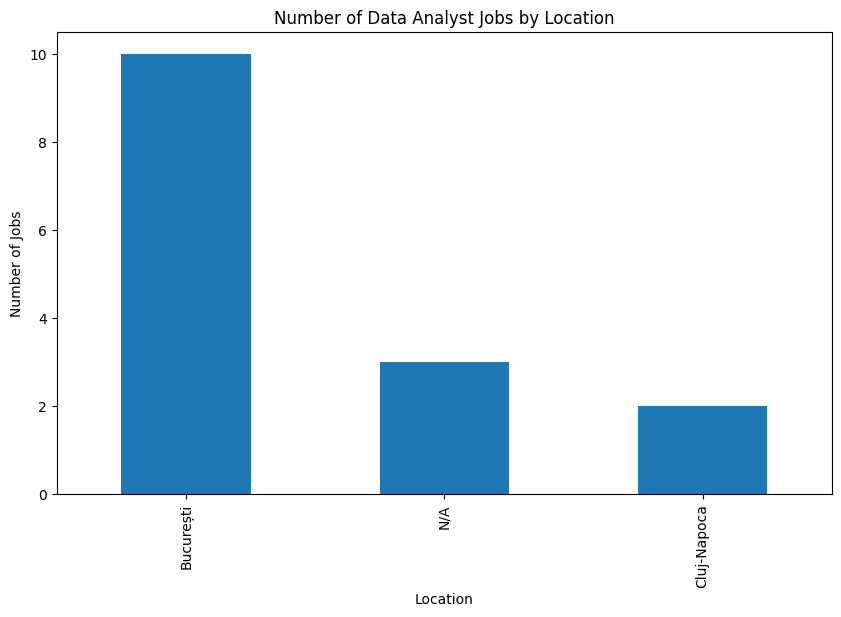

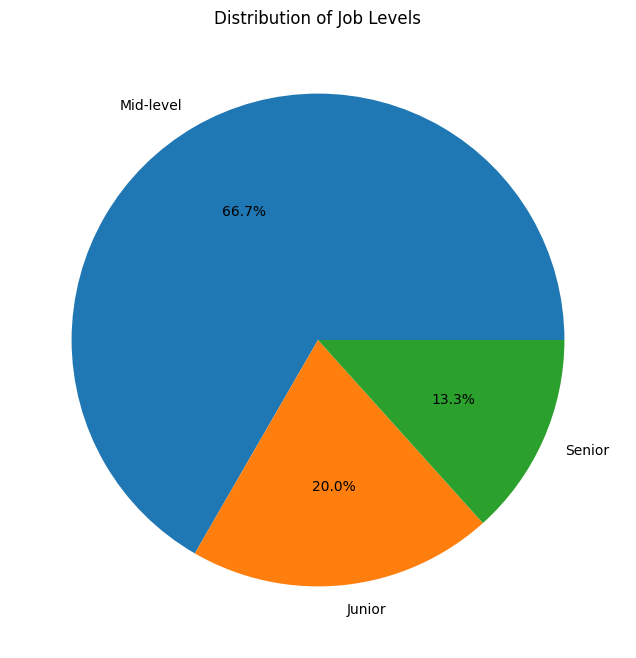

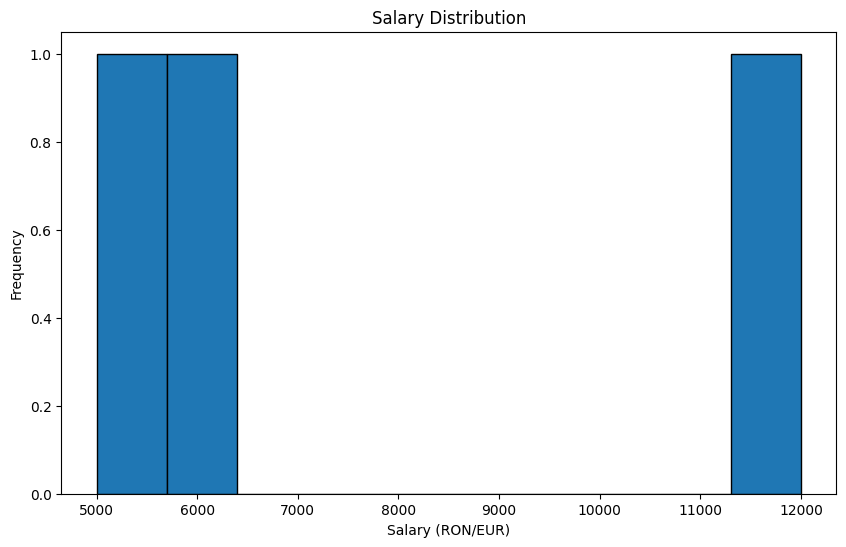

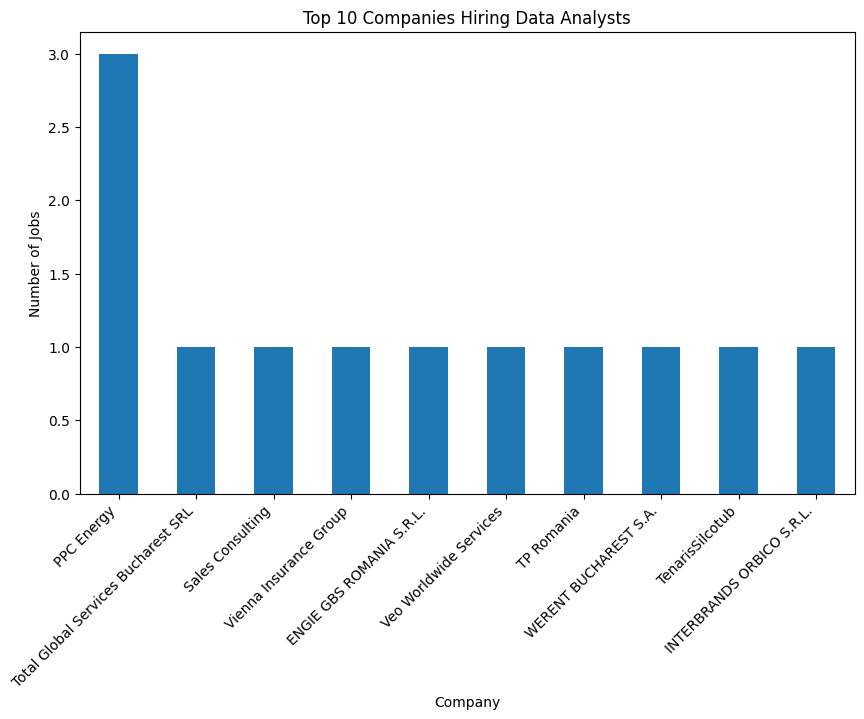

In [31]:
# Data Analysis and Visualization Section

import matplotlib.pyplot as plt

# Summary statistics
print("Summary Statistics:")
print(df_jobs.describe(include='all'))

# Jobs by location
location_counts = df_jobs['Location'].value_counts()
plt.figure(figsize=(10, 6))
location_counts.plot(kind='bar')
plt.title("Number of Data Analyst Jobs by Location")
plt.xlabel("Location")
plt.ylabel("Number of Jobs")
plt.show()

# Jobs by level
level_counts = df_jobs['Level'].value_counts()
plt.figure(figsize=(8, 8))
level_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribution of Job Levels")
plt.show()

# Salary distribution (only for non-null)
salary_data = df_jobs.dropna(subset=['Salary_Num'])
if not salary_data.empty:
    plt.figure(figsize=(10, 6))
    plt.hist(salary_data['Salary_Num'], bins=10, edgecolor='black')
    plt.title("Salary Distribution")
    plt.xlabel("Salary (RON/EUR)")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("No numerical salary data available for visualization.")

# Top companies
company_counts = df_jobs['Company'].value_counts().head(10)
plt.figure(figsize=(10, 6))
company_counts.plot(kind='bar')
plt.title("Top 10 Companies Hiring Data Analysts")
plt.xlabel("Company")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45, ha='right')
plt.show()

In [32]:
# Save Final Data
df_jobs.to_csv("ejobs_data_analyst_cleaned.csv", index=False)
print("Cleaned data saved to ejobs_data_analyst_cleaned.csv")

Cleaned data saved to ejobs_data_analyst_cleaned.csv


# Conclusion

This project successfully demonstrates the end-to-end process of building a web scraper for job data, from data collection to analysis. Key insights:
- Most jobs are in major cities like București.
- Many positions are mid-level, with salaries often confidential.
- Top companies include PPC Energy and others.

## Future Improvements
- Scrape the full 1234 jobs using Selenium for infinite scroll.
- Add NLP for job description analysis.
- Build a dashboard with Streamlit or Dash.

## Portfolio Impact
This project highlights skills in Python, web scraping, data wrangling, and visualization—essential for data analyst roles. Feel free to reach out for questions!

In [7]:
# Inspect the HTML structure to find job listings
print("Finding all div elements that might contain jobs:")
job_containers = soup.find_all('div', class_=True)
for i, container in enumerate(job_containers[:10]):  # First 10
    print(f"{i}: {container.get('class')} - {container.get_text(strip=True)[:100]}")

print("\nFinding h2 elements (job titles):")
titles = soup.find_all('h2')
for title in titles[:5]:
    print(title.get_text(strip=True))

print("\nFinding links with 'locuri-de-munca' in href:")
links = soup.find_all('a', href=lambda x: x and 'locuri-de-munca' in x)
for link in links[:5]:
    print(link.get('href'), link.get_text(strip=True))

Finding all div elements that might contain jobs:
0: ['Page', 'Page--TopBarVisible--fallback', 'app', 'app--fallback-banner'] - Companie nouă?Primești un Anunț Business cu actualizare săptămânală Gratuit (€269)GratisCreează cont
1: ['shared-header-top-banner-fallback'] - Companie nouă?Primești un Anunț Business cu actualizare săptămânală Gratuit (€269)GratisCreează cont
2: ['shared-header-top-banner-fallback__texts'] - Companie nouă?Primești un Anunț Business cu actualizare săptămânală Gratuit (€269)Gratis
3: ['shared-header-top-banner-fallback__new-tag'] - Gratis
4: ['layout-header__item'] - Joburi
5: ['layout-header__item'] - Cariera
6: ['layout-header__item'] - Te joci?
7: ['layout-header__item'] - Salarii
8: ['layout-header__item-wrapper'] - Ofertă Companii
9: ['layout-header__item'] - Ofertă Companii

Finding h2 elements (job titles):
Senior Data Analyst
Marketing Automation Data Analyst
Senior Data Analyst
Nu rata joburile noi!
Nu rata joburile noi!

Finding links with 'locuri-de

In [8]:
# Explore the structure around job titles
titles = soup.find_all('h2')
for i, title in enumerate(titles[:3]):  # First 3
    print(f"Job {i+1}:")
    print(f"Title: {title.get_text(strip=True)}")
    # Find the parent container
    parent = title.find_parent('div')
    if parent:
        print(f"Parent class: {parent.get('class')}")
        # Find company (next h3 or a tag)
        company = parent.find('h3') or parent.find('a', href=lambda x: x and 'company' in x)
        if company:
            print(f"Company: {company.get_text(strip=True)}")
        # Find location
        location = parent.find('span', class_=lambda x: x and 'location' in x.lower()) or parent.find(text=lambda t: t and 'București' in t)
        print(f"Location: {location.strip() if location else 'N/A'}")
    print("---")

Job 1:
Title: Senior Data Analyst
Parent class: ['job-card-content-middle']
Company: PPC Energy
Location: București
---
Job 2:
Title: Marketing Automation Data Analyst
Parent class: ['job-card-content-middle']
Company: PPC Energy
Location: București
---
Job 3:
Title: Senior Data Analyst
Parent class: ['job-card-content-middle']
Company: PPC Energy
Location: București
---


C:\Users\arban\AppData\Local\Temp\ipykernel_25756\3090946288.py:15: DeprecationWarning: The 'text' argument to find()-type methods is deprecated. Use 'string' instead.
  location = parent.find('span', class_=lambda x: x and 'location' in x.lower()) or parent.find(text=lambda t: t and 'București' in t)


In [10]:
# Find all job links
job_links = soup.find_all('a', href=lambda x: x and '/user/locuri-de-munca/' in x)
print(f"Found {len(job_links)} job links")

for link in job_links[:5]:
    print(f"Link: {link.get('href')}")
    print(f"Text: {link.get_text(strip=True)}")
    # Find parent or next elements for company
    parent = link.find_parent('div')
    if parent:
        company = parent.find('a', href=lambda x: x and '/company/' in x)
        if company:
            print(f"Company: {company.get_text(strip=True)}")
    print("---")

Found 6 job links
Link: /user/locuri-de-munca/senior-data-analyst/1940414
Text: Senior Data Analyst
Company: PPC Energy
---
Link: /user/locuri-de-munca/senior-data-analyst/1940414
Text: 
Company: PPC Energy
---
Link: /user/locuri-de-munca/marketing-automation-data-analyst/1940425
Text: Marketing Automation Data Analyst
Company: PPC Energy
---
Link: /user/locuri-de-munca/marketing-automation-data-analyst/1940425
Text: 
Company: PPC Energy
---
Link: /user/locuri-de-munca/senior-data-analyst/1937925
Text: Senior Data Analyst
Company: PPC Energy
---


In [11]:
# Find the main job list
# From the HTML, the jobs are listed in a div or section
job_sections = soup.find_all('div', class_=lambda x: x and 'job' in ' '.join(x).lower())
print(f"Found {len(job_sections)} job-related divs")

# Perhaps the list is in a ul or div with many a tags
all_links = soup.find_all('a', href=lambda x: x and 'locuri-de-munca' in x)
print(f"Total links with locuri-de-munca: {len(all_links)}")

# The main list might be in a div with id or class containing 'results' or 'list'
results_div = soup.find('div', id='results') or soup.find('div', class_=lambda x: x and 'results' in ' '.join(x).lower())
if results_div:
    print("Found results div")
    links_in_results = results_div.find_all('a', href=lambda x: x and '/user/locuri-de-munca/' in x)
    print(f"Job links in results: {len(links_in_results)}")
else:
    print("No results div found")

# Perhaps it's a list of job items
job_items = soup.find_all('li', class_=lambda x: x and 'job' in ' '.join(x).lower())
print(f"Job li items: {len(job_items)}")

# Let's try to find all text that looks like job titles followed by company
import re
text = soup.get_text()
jobs_from_text = re.findall(r'([A-Z][a-zA-Z\s]+?)[A-Z]{2,}', text)  # Rough regex for title COMPANY
print(f"Possible jobs from text: {len(jobs_from_text)}")
for job in jobs_from_text[:10]:
    print(job)

Found 0 job-related divs
Total links with locuri-de-munca: 37
No results div found
Job li items: 0
Possible jobs from text: 86
BP
PV
Senior Data Analyst
Marketing Automation Data Analyst
Senior Data Analyst
Data Analyst 
TEC 
EN
GBS 
ES


In [12]:
import re

# Find all unique job links
job_links = soup.find_all('a', href=re.compile(r'/user/locuri-de-munca/'))
unique_links = list(set(link.get('href') for link in job_links))
print(f"Unique job links: {len(unique_links)}")

# For each unique link, try to find title and company
job_list = []
for href in unique_links[:10]:  # First 10 for test
    link = soup.find('a', href=href)
    if link:
        title = link.get_text(strip=True)
        if title:
            # Find company in the same parent or nearby
            parent = link.find_parent('div')
            company_link = parent.find('a', href=re.compile(r'/company/')) if parent else None
            company = company_link.get_text(strip=True) if company_link else "N/A"
            
            # Location from text
            location = "N/A"
            if parent:
                text = parent.get_text()
                locations = ["București", "Cluj-Napoca", "Iași", "Timișoara", "Brașov", "Constanța", "Craiova", "Galați", "Ploiești", "Oradea"]
                for loc in locations:
                    if loc in text:
                        location = loc
                        break
            
            job_list.append({
                "Job Title": title,
                "Company": company,
                "Location": location,
                "Link": "https://www.ejobs.ro" + href
            })

df = pd.DataFrame(job_list)
print(f"Scraped {len(df)} jobs")
df.head()

Unique job links: 3
Scraped 3 jobs


,Job Title,Company,Location,Link
0,Senior Data Analyst,PPC Energy,București,https://www.ejobs.ro/user/locuri-de-munca/seni...
1,Senior Data Analyst,PPC Energy,București,https://www.ejobs.ro/user/locuri-de-munca/seni...
2,Marketing Automation Data Analyst,PPC Energy,București,https://www.ejobs.ro/user/locuri-de-munca/mark...


In [13]:
# Find containers that have many job links
all_divs = soup.find_all('div')
for div in all_divs:
    links = div.find_all('a', href=re.compile(r'/user/locuri-de-munca/'))
    if len(links) > 2:
        print(f"Div with class {div.get('class')} has {len(links)} job links")
        print(div.get_text()[:200])
        break

# Perhaps the list is in a ul
uls = soup.find_all('ul')
for ul in uls:
    links = ul.find_all('a', href=re.compile(r'/user/locuri-de-munca/'))
    if len(links) > 0:
        print(f"UL has {len(links)} job links")
        for link in links[:3]:
            print(link.get_text(strip=True))

# Perhaps the jobs are listed as text in spans or divs
job_texts = soup.find_all(string=re.compile(r'Data Analyst'))
print(f"Found {len(job_texts)} strings with 'Data Analyst'")
for text in job_texts[:5]:
    print(repr(text))

Div with class None has 6 job links
Companie nouă? Primești un Anunț Business cu actualizare săptămânală Gratuit (€269)GratisCreează contJoburiCarieraTe joci?SalariiOfertă CompaniiCont nouIntra in controenCaută job1Filtredata analystȘte
UL has 6 job links
Senior Data Analyst

Marketing Automation Data Analyst
Found 6 strings with 'Data Analyst'
'Senior Data Analyst'
'Marketing Automation Data Analyst'
'Senior Data Analyst'
'Data Analyst'
'Sales Data Analyst'


In [14]:
# Search for job items
job_items = soup.find_all('div', class_=re.compile(r'job.*item|item.*job|search.*result'))
print(f"Found {len(job_items)} job items")

for item in job_items[:3]:
    print(item.get_text(strip=True)[:100])
    links = item.find_all('a')
    for link in links:
        if '/user/locuri-de-munca/' in link.get('href', ''):
            print(f"Job link: {link.get_text(strip=True)}")

# Perhaps the list is in a script tag with JSON
scripts = soup.find_all('script')
for script in scripts:
    if script.string and 'locuri-de-munca' in script.string:
        print("Found script with job data")
        print(script.string[:500])

# Perhaps the jobs are loaded from an API, look for fetch or xhr in scripts
for script in scripts:
    if script.string and ('fetch' in script.string or 'XMLHttpRequest' in script.string):
        print("Found script with fetch")
        print(script.string[:500])

Found 0 job items
Found script with job data
[["ShallowReactive",1],{"data":2,"state":5,"once":70,"_errors":71,"serverRendered":4,"path":74,"pinia":75},["ShallowReactive",3],{"load-jobs":4,"$ryIt5Y_uRE":4},true,["Reactive",6],{"$snuxt-i18n-meta":7,"$s$UfPBMazHyt":8,"$stime":9,"$squery":10,"$s$tXx7GToM1N":11,"$scardVisibility1":4,"$scardVisibility2":4,"$scardVisibility3":4,"$scardVisibility4":8,"$scardVisibility5":8,"$scardVisibility6":8,"$scardVisibility7":8,"$scardVisibility8":8,"$scardVisibility9":8,"$scardVisibility10":8,"$scardVisibili


In [17]:
# Install Selenium if not already installed
%pip install selenium webdriver-manager

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.5 MB 15.5 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 33.0 MB/s  0:00:00

   ------------- --------------------------  5/15 [pycparser]
   ------------------------ ---------------  9/15 [webdriver-manager]
   -------------------------------- ------- 12/15 [trio]
   -------------------------------- ------- 12/15 [trio]
   ------------------------------------- -- 14/15 [selenium]
   ------------------------------------- -- 14/15 [selenium]
   ------------------------------------- -- 14/15 [selenium]
   ------------------------------------- -- 14/15 [selenium]
   ------------------------------------- -- 14/15 [selenium]
   ------------------------------------- -- 14/15 [selenium]
   ---------------------------------------- 15/15 [selenium]

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
# Example: Using Selenium to scrape dynamic content from ejobs.ro
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import time

# Set up Chrome WebDriver (automatically manages the driver)
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))

# URL to scrape
url = "https://www.ejobs.ro/locuri-de-munca/data-analyst"
driver.get(url)

# Wait for the page to load (adjust timeout as needed)
WebDriverWait(driver, 10).until(EC.presence_of_element_located((By.TAG_NAME, "body")))

# Scroll down to load more jobs (if infinite scroll)
driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
time.sleep(2)  # Wait for content to load

# Now, parse with BeautifulSoup
from bs4 import BeautifulSoup
soup = BeautifulSoup(driver.page_source, "html.parser")

# Extract jobs (similar to before, but now with full HTML)
job_cards = soup.find_all('div', class_='job-card-content-middle')
jobs_list = []

for card in job_cards:
    title = card.find('h2').get_text(strip=True) if card.find('h2') else "N/A"
    company = card.find('h3').get_text(strip=True) if card.find('h3') else "N/A"
    location = "N/A"
    text = card.get_text()
    locations = ["București", "Cluj-Napoca", "Iași", "Timișoara"]
    for loc in locations:
        if loc in text:
            location = loc
            break
    jobs_list.append({"Title": title, "Company": company, "Location": location})

# For the full list, if it's in a specific container
# Example: Find all job titles in the list
all_titles = soup.find_all('h2')
job_titles = [h2.get_text(strip=True) for h2 in all_titles if 'analyst' in h2.get_text().lower() or 'data' in h2.get_text().lower()]

print(f"Found {len(job_titles)} potential job titles with Selenium")

# Close the browser
driver.quit()

# Create DataFrame
df_selenium = pd.DataFrame(jobs_list)
print("Jobs scraped with Selenium:")
print(df_selenium.head())

Found 3 potential job titles with Selenium
Jobs scraped with Selenium:
                               Title     Company   Location
0                Senior Data Analyst  PPC Energy  București
1  Marketing Automation Data Analyst  PPC Energy  București
2                Senior Data Analyst  PPC Energy  București
